In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
import os
df = pd.read_csv("../data/row/cleaned"
".csv")

In [62]:
# Binary Columns
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

In [63]:
# Mapping
for col in binary_cols:

    df[col] = df[col].map({
        "Yes": 1,
        "No": 0,
        "Male": 1,
        "Female": 0
    })

In [64]:
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)

In [65]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1y", "1-2y", "2-4y", "4-6y"]
)

In [66]:
df["ChargeLevel"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 70, 120],
    labels=["Low", "Medium", "High"]
)

In [67]:
# One Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [68]:
# Check missing values
print(df.isnull().sum())

gender                                   0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
AvgCharges                               0
SeniorCitizen_Yes                        0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV

In [69]:
df.head

<bound method NDFrame.head of       gender  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0          0        1           0       1             0                 1   
1          1        0           0      34             1                 0   
2          1        0           0       2             1                 1   
3          1        0           0      45             0                 0   
4          0        0           0       2             1                 1   
...      ...      ...         ...     ...           ...               ...   
7027       1        1           1      24             1                 1   
7028       0        1           1      72             1                 1   
7029       0        1           1      11             0                 1   
7030       1        1           0       4             1                 1   
7031       1        0           0      66             1                 1   

      MonthlyCharges  TotalCharges  Churn  Av

In [70]:
# Replace missing values
df = df.fillna(0)

# Convert bool columns to int
df = df.astype(int)

In [71]:
# Convert bool to int
df = df.astype(int)

In [72]:
df.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgCharges,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2y,TenureGroup_2-4y,TenureGroup_4-6y,ChargeLevel_Medium,ChargeLevel_High
0,0,1,0,1,0,1,29,29,0,14,...,0,0,0,1,0,0,0,0,0,0
1,1,0,0,34,1,0,56,1889,0,53,...,1,0,0,0,1,0,1,0,1,0
2,1,0,0,2,1,1,53,108,1,36,...,0,0,0,0,1,0,0,0,1,0
3,1,0,0,45,0,0,42,1840,0,40,...,1,0,0,0,0,0,1,0,1,0
4,0,0,0,2,1,1,70,151,1,50,...,0,0,0,1,0,0,0,0,0,1


In [73]:
# Check data types
print(df.dtypes)

gender                                   int64
Partner                                  int64
Dependents                               int64
tenure                                   int64
PhoneService                             int64
PaperlessBilling                         int64
MonthlyCharges                           int64
TotalCharges                             int64
Churn                                    int64
AvgCharges                               int64
SeniorCitizen_Yes                        int64
MultipleLines_No phone service           int64
MultipleLines_Yes                        int64
InternetService_Fiber optic              int64
InternetService_No                       int64
OnlineSecurity_No internet service       int64
OnlineSecurity_Yes                       int64
OnlineBackup_No internet service         int64
OnlineBackup_Yes                         int64
DeviceProtection_No internet service     int64
DeviceProtection_Yes                     int64
TechSupport_N

In [74]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

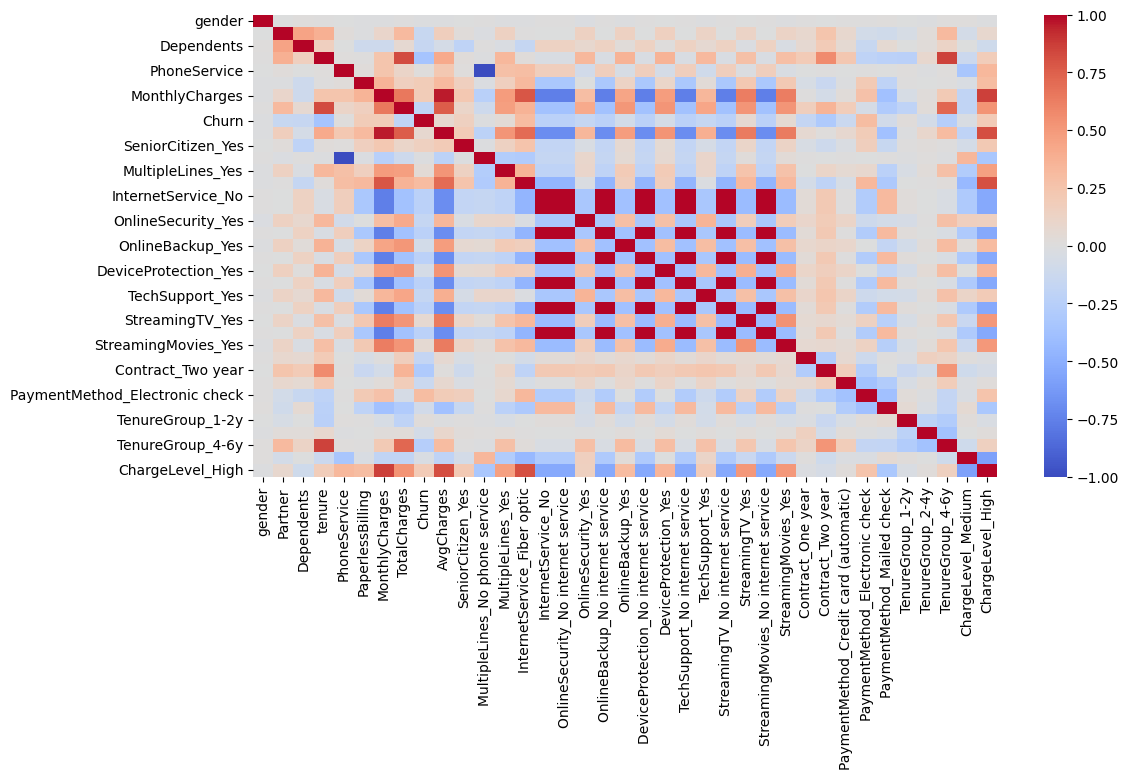

In [77]:

plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [78]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

X_cat = df.copy()

y = X_cat["Churn"]
X_cat = X_cat.drop("Churn", axis=1)

chi_scores, p_values = chi2(X_cat, y)

chi_df = pd.DataFrame({
    "Feature": X_cat.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print(chi_df)

                                  Feature     Chi2 Score        p-value
7                            TotalCharges  629765.414590   0.000000e+00
3                                  tenure   16377.328093   0.000000e+00
6                          MonthlyCharges    3682.622856   0.000000e+00
8                              AvgCharges     563.167271  1.720420e-124
27                      Contract_Two year     486.223101  9.454286e-108
29         PaymentMethod_Electronic check     424.113152   3.105849e-94
12            InternetService_Fiber optic     372.082851   6.587130e-83
33                       TenureGroup_4-6y     334.140721   1.204896e-74
20        TechSupport_No internet service     285.475152   4.814000e-64
14     OnlineSecurity_No internet service     285.475152   4.814000e-64
22        StreamingTV_No internet service     285.475152   4.814000e-64
16       OnlineBackup_No internet service     285.475152   4.814000e-64
13                     InternetService_No     285.475152   4.814

In [79]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [80]:
selected_features = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_
})

print(selected_features)

                                  Feature  Selected
0                                  gender     False
1                                 Partner     False
2                              Dependents     False
3                                  tenure      True
4                            PhoneService     False
5                        PaperlessBilling     False
6                          MonthlyCharges     False
7                            TotalCharges      True
8                              AvgCharges      True
9                       SeniorCitizen_Yes     False
10         MultipleLines_No phone service     False
11                      MultipleLines_Yes     False
12            InternetService_Fiber optic      True
13                     InternetService_No     False
14     OnlineSecurity_No internet service     False
15                     OnlineSecurity_Yes     False
16       OnlineBackup_No internet service     False
17                       OnlineBackup_Yes     False
18   DeviceP

In [81]:
df.to_csv('../data/processed/data_after_cleend_scaled.csv', index=False)